In [3]:
# !pip install opendatasets
# !pip install legacy-cgi

In [1]:
import opendatasets as od

In [2]:
od.download("https://www.kaggle.com/datasets/jessicali9530/celeba-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset


100%|██████████| 1.33G/1.33G [05:26<00:00, 4.38MB/s]


In [ ]:
import cv2

image = cv2.imread("/content/celeba-dataset/img_align_celeba/img_align_celeba/000001.jpg")
image.shape

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [6]:
latent_dim = 100
img_shape = (28, 28, 3)
BATCH_SIZE = 128
EPOCHS = 10

def build_generator():
    model = tf.keras.Sequential()
    # Project and reshape
    model.add(layers.Dense(7 * 7 * 128, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Reshape((7, 7, 128)))

    # Upsample to 14x14
    model.add(layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Upsample to 28x28
    model.add(layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))

    # Final layer
    model.add(layers.Conv2DTranspose(3, (3, 3), strides=(1, 1), padding='same', use_bias=False, activation='tanh'))
    return model

In [7]:
def build_discriminator():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', input_shape=img_shape))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

Found 202599 files.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10 | Generator Loss: 0.7364 | Discriminator Loss: 1.4053
Epoch 2/10 | Generator Loss: 0.7412 | Discriminator Loss: 1.3458
Epoch 3/10 | Generator Loss: 0.8094 | Discriminator Loss: 1.2470
Epoch 4/10 | Generator Loss: 0.7626 | Discriminator Loss: 1.2768
Epoch 5/10 | Generator Loss: 0.7343 | Discriminator Loss: 1.3491
Epoch 6/10 | Generator Loss: 0.8198 | Discriminator Loss: 1.2534
Epoch 7/10 | Generator Loss: 0.8120 | Discriminator Loss: 1.2339
Epoch 8/10 | Generator Loss: 0.7929 | Discriminator Loss: 1.2662
Epoch 9/10 | Generator Loss: 1.4908 | Discriminator Loss: 0.9104
Epoch 10/10 | Generator Loss: 0.8328 | Discriminator Loss: 1.2624


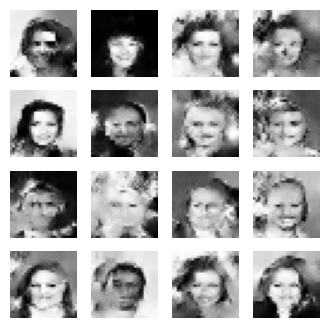

In [8]:
# 4. Define Loss and Optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator wants the discriminator to output 1 (real) for fake images
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

# 5. Training Step
@tf.function
def train_step(images):
    noise = tf.random.normal([tf.shape(images)[0], latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

# 6. Dataset Preparation
train_images = tf.keras.utils.image_dataset_from_directory(
    "/content/celeba-dataset/img_align_celeba/img_align_celeba",
        labels=None,
     image_size=(28, 28),
    batch_size=BATCH_SIZE,
    shuffle=True
    )
# Normalize to [-1, 1] to match the tanh activation of the generator
#train_images = train_images.reshape(train_images.shape[0], 212, 176, 3).astype('float32')
#train_images = (train_images - 127.5) / 127.5
train_images = train_images.map(
    lambda x: (tf.cast(x, tf.float32) / 127.5) - 1
)

#train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(BATCH_SIZE)

# Initialize models
generator = build_generator()
discriminator = build_discriminator()

# 7. Training Loop
for epoch in range(EPOCHS):
    for image_batch in train_images:
        g_loss, d_loss = train_step(image_batch)
    print(f'Epoch {epoch+1}/{EPOCHS} | Generator Loss: {g_loss:.4f} | Discriminator Loss: {d_loss:.4f}')

# 8. Generate and Plot Images
def generate_and_save_images(model, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        # Rescale from [-1, 1] back to [0, 1] for plotting
        plt.imshow((predictions[i, :, :, 0] + 1) / 2.0, cmap='gray')
        plt.axis('off')
    plt.show()

seed = tf.random.normal([16, latent_dim])
generate_and_save_images(generator, seed)

In [9]:
def generate_and_save_images(model, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)

        # [-1, 1] -> [0, 1]
        plt.imshow((predictions[i] + 1) / 2.0)

        plt.axis('off')

    plt.show()

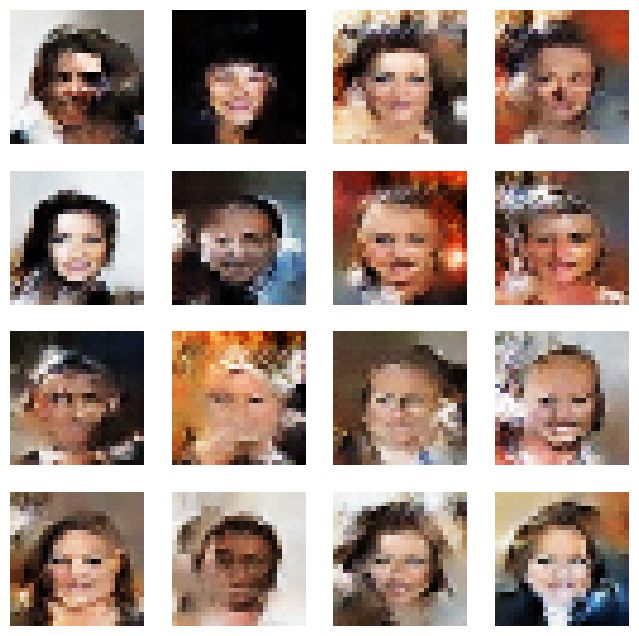

In [10]:
generate_and_save_images(generator, seed)